In [1]:
# reading data
## Example with GridSearch CV
#https://stackoverflow.com/questions/38555650/try-multiple-estimator-in-one-grid-search/53292354
import csv
import re
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
from sklearn.metrics import f1_score, make_scorer, classification_report
import pandas as pd
from sklearn.metrics import classification_report
import spacy
nlp = spacy.load("en_core_web_sm") 

In [2]:
path = 'hatespeech_text_label_vote_RESTRICTED_100K.csv'

#tweet, label, number of voters

In [3]:
tweets = []
labels = []
with open(path) as fi:
    data = csv.reader(fi, delimiter='\t')
    for row in data:
        tweets.append(row[0])
        labels.append(row[1]) 

In [4]:
## sanity checks
print(len(tweets) == len(labels))
print(len(tweets))

True
99996


In [5]:
# Classes are not balanced... this has implications for the training procedure.
Counter(labels)

Counter({'normal': 53851, 'abusive': 27150, 'spam': 14030, 'hateful': 4965})

<BarContainer object of 4 artists>

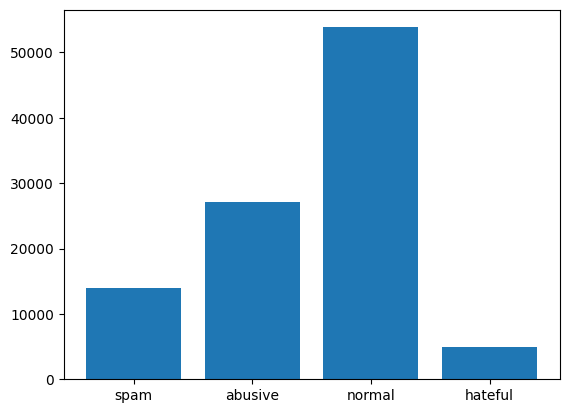

In [6]:
plt.bar(Counter(labels).keys(), Counter(labels).values())

In [4]:
X_train, X_test, y_train, y_test = train_test_split(tweets, labels, test_size=0.2, random_state=42) 


In [8]:
y_train[0]

'abusive'

In [9]:
X_train[0]


'RT @paytons_hawtmom: I knew that girl was fucking Sierra husband &#128514;&#128514;&#128514; #LHHATL'

In [10]:
# Print a few tweets and labels to inspect the data
for i in range(5):
    print(f"Label: {y_train[i]}\nTweet: {X_train[i]}\n")

Label: abusive
Tweet: RT @paytons_hawtmom: I knew that girl was fucking Sierra husband &#128514;&#128514;&#128514; #LHHATL

Label: abusive
Tweet: RT @SheaSerrano: SHE FUCKING DID IT!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

Label: normal
Tweet: What happened with all the people concerned about Flynn's alleged story? There was no Russian collusion glad that is over. #Trump #Russia

Label: normal
Tweet: When you are ready to make excuses and give up... Think of the adversity these folks overcome https://t.co/U06W3gPQBg

Label: normal
Tweet: @garyashley5 @sommecourt This is a much better picture (not mine - from Pinterest) https://t.co/NnlzSikEpK



In [8]:
# one example solution
pipeline = Pipeline(steps = [('vectorizer', TfidfVectorizer()), ('classifier', LogisticRegression(solver='liblinear'))])


In [12]:

grid = {
    'vectorizer__ngram_range' : [(1,1), (1,2)],
    'vectorizer__max_df': [0.5, 0.75, 1.0],
    'vectorizer__min_df': [1, 5],
    'classifier__C': [0.01, 1, 100]
}

#f1 = make_scorer(f1_score, average='macro') # macro --> emphasizes the prediction of the smaller classes (in this case: hateful/ spam)

search = GridSearchCV(estimator=pipeline,
                      param_grid=grid,
                      scoring='f1_macro',
                      cv=3,
                      n_jobs=-3,  # use all cpus but 2: leave 2 for other tasks
                      verbose=10)
                      
search.fit(X_train, y_train)
print(f'Using these hyperparameters {search.best_params_}, we get the best performance.')


Fitting 3 folds for each of 36 candidates, totalling 108 fits


c:\Users\stolw010\AppData\Local\anaconda3\envs\gesis_iml\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


Using these hyperparameters {'classifier__C': 100, 'vectorizer__max_df': 0.75, 'vectorizer__min_df': 1, 'vectorizer__ngram_range': (1, 2)}, we get the best performance.


In [13]:
print(classification_report(y_test, search.predict(X_test)))

              precision    recall  f1-score   support

     abusive       0.87      0.90      0.89      5369
     hateful       0.58      0.28      0.38       966
      normal       0.84      0.88      0.85     10848
        spam       0.57      0.53      0.55      2817

    accuracy                           0.80     20000
   macro avg       0.71      0.65      0.67     20000
weighted avg       0.80      0.80      0.80     20000



In [14]:
#what about the gridsearch results for other parameter combinations?
results = pd.DataFrame(search.cv_results_)
results = results.sort_values(by='mean_test_score', ascending=False)
results[['param_vectorizer__ngram_range', 'param_vectorizer__max_df', 'param_vectorizer__min_df', 'param_classifier__C', 'mean_test_score', 'std_test_score']]
# reading data
## Example with GridSearch CV

,param_vectorizer__ngram_range,param_vectorizer__max_df,param_vectorizer__min_df,param_classifier__C,mean_test_score,std_test_score
33,"(1, 2)",1.00,1,100.00,0.659725,0.003816
29,"(1, 2)",0.75,1,100.00,0.659725,0.003816
28,"(1, 1)",0.75,1,100.00,0.647978,0.004347
32,"(1, 1)",1.00,1,100.00,0.647978,0.004347
25,"(1, 2)",0.50,1,100.00,0.647469,0.005231
24,"(1, 1)",0.50,1,100.00,0.638211,0.004016
16,"(1, 1)",0.75,1,1.00,0.633624,0.003197
20,"(1, 1)",1.00,1,1.00,0.633624,0.003197
21,"(1, 2)",1.00,1,1.00,0.627851,0.005080
17,"(1, 2)",0.75,1,1.00,0.627851,0.005080


Note that the top2 is actually a tie, or more precisely: max_df=0.75 appears to yield equal results to max_df=1, why would that be?
Also note that the better F1s are reaching in this example by introducing the largest bias (C=100 to avoid overfitting)

In [15]:
#inspect what the max_df parameter does:

# Fit the vectorizer on X_train
vectorizer = TfidfVectorizer()
X_vec = vectorizer.fit_transform(X_train)

# Calculate document frequency for each word
df = np.asarray((X_vec > 0).sum(axis=0)).flatten() / X_vec.shape[0]

# Get feature names
words = np.array(vectorizer.get_feature_names_out())

# Find words with document frequency between 0.5 and 0.75
mask = (df >= 0.5) & (df <= 0.75)
selected_words = words[mask]

print(selected_words)

masktop = (df >= 0.75)
selected_words_top = words[masktop]
print(selected_words_top)

['co' 'https']
[]


#### Other options to try: 
- Different preprocessing steps (e.g., stopword removal, different tokenizers, stemming, lemmatization, ...)
- Different vectorizers (e.g. CountVectorizer())
- Different classifiers (e.g., MultinomialNB(), SVC())
- Class weights
- ...

In [16]:
# Import NLTK's stopwords and word_tokenize
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download stopwords and punkt if not already present
nltk.download('stopwords')
nltk.download('punkt')

# Define stopwords list
stopwords_list = stopwords.words('english')

# Define a simple preprocessor: lowercase and remove punctuation
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text) # remove punctuation: [^a-zA-Z0-9\s] matches any character that is not a letter, digit, or whitespace.
    return text

# Define a tokenizer using NLTK's word_tokenize
def tokenizer(text):
    return word_tokenize(text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\stolw010/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\stolw010/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [17]:
advanced_grid = {'vectorizer__stop_words':[None, stopwords_list], # stopword removal
        'vectorizer__max_df':[0.4, 1.0], # exclude terms in more than *40%* or 100% of the docs
        #'vectorizer__min_df':[1, 5], left this out since min_df=1 yielded best results above, but optional could exclude terms in less than 1 or 5 documents. #why could this still matter?
        'vectorizer__ngram_range':[(1,1), (1,2)], # consider only unigrams, or both unigrams and bigrams
        #'vectorizer__preprocessor':[None, preprocess], # No preprocessing, or custom preprocessor function
        'vectorizer__tokenizer':[None, tokenizer], # word (=whitespace) or 'tokenizer' for your custom tokenizer 
        'classifier__class_weight':[None, 'balanced'] # class weights: None or balanced.
        }

In [18]:
search2 = GridSearchCV(estimator=pipeline, # first vectorizer, then classifier
                      param_grid=advanced_grid, # test the new parameters
                      scoring='f1_macro',     # optimise for macro f1 score (note: we want good performance for all classes )
                      cv=3, # 3-fold cross validation 
                      n_jobs=-1,  # use all cpus
                      verbose=1,
                      error_score='raise') # print some output

search2.fit(X_train, y_train)
print(f'Using these hyperparameters {search2.best_params_}, we get the best performance.')


Fitting 3 folds for each of 32 candidates, totalling 96 fits


c:\Users\stolw010\AppData\Local\anaconda3\envs\gesis_iml\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


Using these hyperparameters {'classifier__class_weight': 'balanced', 'vectorizer__max_df': 1.0, 'vectorizer__ngram_range': (1, 1), 'vectorizer__stop_words': None, 'vectorizer__tokenizer': None}, we get the best performance.


In [19]:
print(classification_report(y_test, search2.predict(X_test)))

              precision    recall  f1-score   support

     abusive       0.89      0.87      0.88      5369
     hateful       0.49      0.39      0.43       966
      normal       0.85      0.84      0.84     10848
        spam       0.54      0.63      0.58      2817

    accuracy                           0.80     20000
   macro avg       0.69      0.68      0.68     20000
weighted avg       0.80      0.80      0.80     20000



In [ ]:
#try with spacy lemmatization
#WARNING: this can be slow [30+ minutes for me], since spacy only allows 1 cpu and needs to be loaded



def spacy_lemmatizer(text):
    doc = nlp(text)
    return [token.lemma_ for token in doc]

advanced_grid2 = {#'vectorizer__stop_words':[None, stopwords_list], # stopword removal #left this out since not compatibel with spacy tokenizer, should remove stopwords in spacy tokenizer instead
        #'vectorizer__max_df':[0.4, 1.0], # exclude terms in more than *40%* or 100% of the docs #left this out since max_df=1.0 yielded best results above
        #'vectorizer__min_df':[1, 5], left this out since min_df=1 yielded best results above, but optional could exclude terms in less than 1 or 5 documents. #why could this still matter?
        'vectorizer__ngram_range':[(1,1), (1,2)], # consider only unigrams, or both unigrams and bigrams
        #'vectorizer__preprocessor':[None, preprocess], # No preprocessing, or custom preprocessor function
        'vectorizer__tokenizer':[None, spacy_lemmatizer], # word (=whitespace) or 'tokenizer' for your custom tokenizer 
        'classifier__class_weight':[None, 'balanced'] # class weights: None or balanced.
        }

search3 = GridSearchCV(estimator=pipeline, param_grid=advanced_grid2, scoring='f1_macro',     # optimise for macro f1 score (note: we want good performance for all classes )
                      cv=2, # 2-fold cross validation, since this can be slow with spacy
                      n_jobs=1,  # use only one cpu, to avoid issues with multiple processes with spaCy
                      verbose=1)

search3.fit(X_train, y_train)
print(f'Using these hyperparameters {search3.best_params_}, we get the best performance.')
print(classification_report(y_test, search3.predict(X_test)))


In [6]:
# Faster alternative: perform a separate gridsearch for spacy lemmatizer (still 10+ minutes for me):

# Pre-lemmatize all texts with spaCy (do this ONCE)
def lemmatize_texts(texts):
    return [" ".join([token.lemma_ for token in nlp(text)]) for text in texts]

X_train_lem = lemmatize_texts(X_train)
X_test_lem = lemmatize_texts(X_test)

In [5]:
spacy_grid = {
        'vectorizer__ngram_range':[(1,1), (1,2)], # consider only unigrams, or both unigrams and bigrams
        'classifier__class_weight':[None, 'balanced'] # class weights: None or balanced.
        }

In [9]:
# Run GridSearchCV as usual, but only on the lemmatized data
search_spacy = GridSearchCV(estimator=pipeline, param_grid=spacy_grid, scoring='f1_macro',     # optimise for macro f1 score (note: we want good performance for all classes )
                      cv=3, # 3-fold cross validation 
                      n_jobs=-1,  # use all cpus
                      verbose=1)
search_spacy.fit(X_train_lem, y_train)
print(f'Using these hyperparameters {search_spacy.best_params_}, we get the best performance.')
print(classification_report(y_test, search_spacy.predict(X_test_lem)))


Fitting 3 folds for each of 4 candidates, totalling 12 fits


c:\Users\stolw010\AppData\Local\anaconda3\envs\gesis_iml\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


Using these hyperparameters {'classifier__class_weight': 'balanced', 'vectorizer__ngram_range': (1, 1)}, we get the best performance.
              precision    recall  f1-score   support

     abusive       0.89      0.88      0.88      5369
     hateful       0.48      0.39      0.43       966
      normal       0.85      0.83      0.84     10848
        spam       0.53      0.63      0.58      2817

    accuracy                           0.79     20000
   macro avg       0.69      0.68      0.68     20000
weighted avg       0.80      0.79      0.80     20000



#### much, much faster

In [10]:
#Maybe check other classifiers?:

pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('classifier', LogisticRegression(solver='liblinear'))  # default, will be overridden by param_grid
])

grid_classifier = [
    {
        'classifier': [LogisticRegression(solver='liblinear')],
        'vectorizer__ngram_range': [(1,1), (1,2)],
        'vectorizer__min_df': [1, 5],
        'classifier__C': [1, 100]
    },
    {
        'classifier': [MultinomialNB()],
        'vectorizer__ngram_range': [(1,1), (1,2)],
        'vectorizer__min_df': [1, 5],
        'classifier__alpha': [1, 100]  # NB's smoothing parameter
    }
]

search_classifier = GridSearchCV(
    estimator=pipeline,
    param_grid=grid_classifier,
    scoring='f1_macro',
    cv=3,
    n_jobs=-3,
    verbose=10 #extensive output
)

search_classifier.fit(X_train, y_train)

print(f'Using these hyperparameters {search_classifier.best_params_}, we get the best performance.')
print(classification_report(y_test, search_classifier.predict(X_test)))

Fitting 3 folds for each of 16 candidates, totalling 48 fits


c:\Users\stolw010\AppData\Local\anaconda3\envs\gesis_iml\lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


Using these hyperparameters {'classifier': LogisticRegression(solver='liblinear'), 'classifier__C': 100, 'vectorizer__min_df': 1, 'vectorizer__ngram_range': (1, 2)}, we get the best performance.
              precision    recall  f1-score   support

     abusive       0.87      0.90      0.89      5369
     hateful       0.58      0.28      0.38       966
      normal       0.84      0.88      0.85     10848
        spam       0.57      0.53      0.55      2817

    accuracy                           0.80     20000
   macro avg       0.71      0.65      0.67     20000
weighted avg       0.80      0.80      0.80     20000



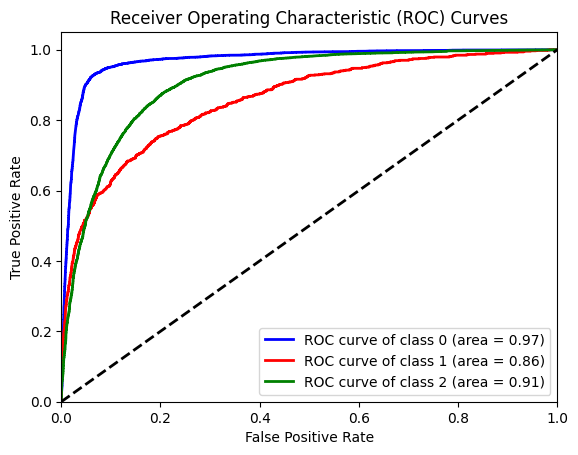

In [11]:
#look at ROC curves for the best model:
from sklearn.metrics import roc_curve, auc
y_prob = search_classifier.predict_proba(X_test)
y_test_binarized = pd.get_dummies(y_test, drop_first=False).values  #binarize the output labels for multiclass ROC AUC
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = y_test_binarized.shape[1]
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
# Plot ROC curves for each class
plt.figure()
colors = ['blue', 'red', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))  
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc="lower right")
plt.show()

In [ ]:
#%pip install eli5 #uncomment if eli5 is not installed yet


   ---------------------------------------- 0/3 [tabulate]
   ------------- -------------------------- 1/3 [graphviz]
   ------------- -------------------------- 1/3 [graphviz]
   ------------- -------------------------- 1/3 [graphviz]
   ------------- -------------------------- 1/3 [graphviz]
   ------------- -------------------------- 1/3 [graphviz]
   -------------------------- ------------- 2/3 [eli5]
   -------------------------- ------------- 2/3 [eli5]
   -------------------------- ------------- 2/3 [eli5]
   -------------------------- ------------- 2/3 [eli5]
   -------------------------- ------------- 2/3 [eli5]
   -------------------------- ------------- 2/3 [eli5]
   -------------------------- ------------- 2/3 [eli5]
   -------------------------- ------------- 2/3 [eli5]
   ---------------------------------------- 3/3 [eli5]

Note: you may need to restart the kernel to use updated packages.


In [17]:
#inspect weights of the logistic regression model:
import eli5

eli5.show_weights(search_classifier.best_estimator_.named_steps['classifier'],
                  vec=search_classifier.best_estimator_.named_steps['vectorizer'],
                  top=20)

In [22]:
weights_df = eli5.format_as_dataframe(
    eli5.explain_weights(search_classifier.best_estimator_.named_steps['classifier'],
                  vec=search_classifier.best_estimator_.named_steps['vectorizer'],
                  top=None)
)

In [27]:
weights_df.head(10)

,target,feature,weight
0,abusive,fucking,92.041838
1,abusive,fucked,58.527323
2,abusive,fuck,45.944272
3,abusive,shit,44.245114
4,abusive,bitch,33.016797
5,abusive,idiots,31.945760
6,abusive,ass,30.406091
7,abusive,idiot,29.889998
8,abusive,fuckin,25.892986
9,abusive,shitty,22.186845


In [34]:
#find the texts which were incorrectly classified by the best model
y_pred = search_classifier.predict(X_test)
X_test = np.array(X_test)
incorrectly_classified = X_test[y_pred != y_test]


In [41]:
# Find the top5 predictive words for predicted class per document that was incorrectly classified
# (based on absolute weight, i.e. most positive or most negative)
# and add these in a column to a pd.DataFrame 
from eli5 import explain_prediction

# Find indices of incorrectly classified samples
incorrect_indices = np.where(y_pred != y_test)[0]

top5_words_per_doc = []

for idx in incorrect_indices[:10]:  # limit to first 10 for speed
    text = X_test[idx]
    pred_class = search_classifier.predict([text])[0]
    exp = explain_prediction(
        search_classifier.best_estimator_.named_steps['classifier'],
        text,
        vec=search_classifier.best_estimator_.named_steps['vectorizer'],
        top=None,
        target_names=search_classifier.classes_
    )
    pos_weights = [
        (w.feature, abs(w.weight))
        for w in exp.targets[search_classifier.classes_.tolist().index(pred_class)].feature_weights.pos
    ]
    neg_weights = [
        (w.feature, abs(w.weight))
        for w in exp.targets[search_classifier.classes_.tolist().index(pred_class)].feature_weights.neg
    ]
    top5_pos = sorted(pos_weights, key=lambda x: -x[1])[:5]
    top5_neg = sorted(neg_weights, key=lambda x: -x[1])[:5]
    top5_words_per_doc.append({
        'text': text,
        'true_label': y_test[idx],
        'predicted_label': pred_class,
        'top5_words_pos': [w[0] for w in top5_pos],
        'top5_words_neg': [w[0] for w in top5_neg]
    })

top_predictors_df = pd.DataFrame(top5_words_per_doc)



In [42]:
print(top_predictors_df.head(10))

                                                text true_label  \
0  Just Listed 5017 Graziano in Southern Highland...     normal   
1  Happy birthday to one of the cuck bois&#128553...    abusive   
2  I added a video to a @YouTube playlist https:/...       spam   
3  Resent wedding set up at @themeldrum. Get in t...       spam   
4  @GoldenTri141921 As I have said a million time...    hateful   
5  They were retarded when they made snowplowing ...    hateful   
6  Apart from gaz all the geordies are annoying t...    abusive   
7  I liked a @YouTube video https://t.co/48MUhptF...       spam   
8  Bundesliga hot-shots face off in Germany's 'Kl...       spam   
9  RT @EfanIfor: The lunacy and identity of #Brit...    hateful   

  predicted_label                                     top5_words_pos  \
0            spam            [ft, new, southern, coming soon, https]   
1          normal     [<BIAS>, happy, the, happy birthday, birthday]   
2          normal                  [<BIAS>, ce

#### NOTE
In eli5 explanations, you may see `<BIAS>` listed with a weight. This shows how much the intercept (bias term) contributes to the model's decision for that class, independent of the input features.

So, `<BIAS>` is not a word from your data, but the model's learned intercept for the class.


In [ ]:
# %pip install shap #uncomment if shap is not installed yet

In [ ]:
#### Smarter use the explainable AI package Shapley

###warning this can be slow for large datasets/models, just a demo here

import shap

#pick the best model:
# Fit your model as usual
search_classifier.fit(X_train, y_train)

# Use the model's predict_proba for SHAP
explainer = shap.KernelExplainer(search_classifier.predict_proba, X_train[:100])  # use a sample for background
shap_values = explainer.shap_values(X_test[:10])  # explain a few test samples

# Visualize
shap.summary_plot(shap_values, X_test[:10])